# **Libraries**

In [1]:
import subprocess, sys

pkgs = [
    "torch", "torchvision",
    "torchaudio",
    "open_clip_torch",
    "transformers",
    "nibabel",
    "scipy",
    "Pillow",
    "matplotlib",
    "tqdm",
]
for p in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", p, "-q"])
print("all packages are ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
all packages are ready


In [2]:
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from open_clip import create_model_from_pretrained
from torch.utils.data import Dataset, DataLoader
from typing import Dict, List, Optional, Tuple
import os, json, time, math, logging
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torch.optim import AdamW
from pathlib import Path
import torch.nn as nn
from PIL import Image
import numpy as np
import torch

In [3]:
try:
    import nibabel as nib
    HAS_NIBABEL = True
except ImportError:
    HAS_NIBABEL = False
    print("nibabel not found")

In [4]:
try:
    import open_clip
    HAS_OPENCLIP = True
except ImportError:
    HAS_OPENCLIP = False

In [5]:
try:
    from transformers import AutoTokenizer, CLIPModel
    HAS_HF = True
except ImportError:
    HAS_HF = False

In [6]:
logging.basicConfig(level=logging.WARNING)
print(f"pyTorch {torch.__version__}, cuda available: {torch.cuda.is_available()}")

pyTorch 2.10.0+cu128, cuda available: True


# **Configuration**

In [7]:
CFG = dict(
    # paths
    images_root = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData",
    text_root = "/kaggle/input/datasets/aminaghandouz/textbrats20/TextBraTSData",
    output_dir = "./checkpoints",
    checkpoint = None, 

    # file suffixes
    flair_suffix = "_flair.nii",
    mask_suffix = "_seg.nii",
    text_suffix = "_flair_text.txt",
    token_suffix = "_flair_text.npy",

    # dataset split
    train_ratio = 0.70,
    val_ratio = 0.15, # remaining 0.15 for test
    split_seed = 42,

    # model
    clip_api = "openclip",
    arch = "ViT-B-16",
    pretrained = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224",
    d_v=768, # ViT hidden dim (ViT-B = 768) 
    d_t=768, # text hidden dim 768
    d_s=256, # PVL bottleneck dim
    d_a=64, # PVL attention head dim
    beta=2.35, # PVL confidence penalty
    patch_grid=14, # sqrt(n_patches) for ViT-B/16 on 224px
    n_upscale=2, # nbr of 2x upscale blocks in seg head
    n_vis_layers=12, # nbr of ViT transformer layers
    n_txt_layers=12, # nbr of text transformer layers

    # training
    epochs=20, batch_size=8, lr=1e-5, lr_min=1e-6,
    weight_decay=1e-4, val_every=1, save_every=10,

    # losses
    lambda_seg=20.0, lambda_dhn=0.001, lambda_scon=0.001,
    tau_dhn=0.1, beta1=1.0, beta2=1.0, tau_scon=0.1,

    # data
    image_size=224, max_text_len=256, num_workers=4,

    seed=42,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

In [8]:
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Path(CFG["output_dir"]).mkdir(parents=True, exist_ok=True)
print(f"device: {DEVICE}, output: {CFG['output_dir']}")

device: cuda, output: ./checkpoints


# **Hybrid Model**

In [9]:
class HybridMedCLIPSeg(nn.Module):
    def __init__(
        self,
        clip_model,
        d_v: int = CFG["d_v"],
        d_t: int = CFG["d_t"],                 
        d_s: int = CFG["d_s"],                 
        d_a: int = CFG["d_a"],                 
        beta: float = CFG["beta"],
        patch_grid: int = CFG["patch_grid"],
        n_upscale: int = CFG["n_upscale"],
        n_vis_layers: int = CFG["n_vis_layers"],
        n_txt_layers: int = CFG["n_txt_layers"],
    ):
        super().__init__()
        self.clip = clip_model
        self.d_v = d_v
        self.d_t = d_t

        # freeze CLIP
        for param in self.clip.parameters():
            param.requires_grad_(False)

        # PVL Adapters (one per ViT layer and one per text layer)
        print(f"Creating vision adapters: query=d_v={d_v}, context=d_t={d_t}")
        self.vis_adapters = nn.ModuleList([
            PVLAdapter(d_v=d_v, d_t=d_t, d_s=d_s, d_a=d_a, beta=beta) 
            for _ in range(n_vis_layers)
        ])

        # text-side adapters: text (768) as query, vision (768) as context
        print(f"Creating text adapters: query=d_t={d_t}, context=d_v={d_v}")
        self.txt_adapters = nn.ModuleList([
            PVLAdapter(d_v=d_t, d_t=d_v, d_s=d_s, d_a=d_a, beta=beta)
            for _ in range(n_txt_layers)
        ])

        self.text_proj_to_internal = nn.Linear(512, d_t, bias=False)
        nn.init.eye_(self.text_proj_to_internal.weight[:min(512, d_t), :])

        # Segmentation head
        self.seg_head = SegmentationHead(d_v, patch_grid, n_upscale)
        self.patch_grid = patch_grid
        self.n_vis_layers = n_vis_layers
        self.n_txt_layers = n_txt_layers

    # internal helpers to extract layer lists from different CLIP APIs
    def _get_vis_layers(self):
        enc = self.clip.visual
        if hasattr(enc, 'transformer') and hasattr(enc.transformer, 'resblocks'):
            return enc.transformer.resblocks
        if hasattr(enc, "trunk") and hasattr(enc.trunk, "blocks"):
            return enc.trunk.blocks
        if hasattr(enc, 'encoder'):
            return enc.encoder.layers
        if hasattr(enc, 'transformer') and hasattr(enc.transformer, 'layers'):
            return enc.transformer.layers
        raise AttributeError(f"couldn't find vision layers in {type(enc)}")

    def _get_txt_layers(self):
        enc = self.clip.text 
        if hasattr(enc, 'transformer'):
            hf_model = enc.transformer 
            if hasattr(hf_model, 'encoder'):
                return hf_model.encoder.layer
        raise AttributeError(
            f"can't find transformer layers inside {type(enc)}"
            f"available attrs: {[a for a in dir(enc) if not a.startswith('_')]}"
        )

    # open-CLIP style forward (used by BiomedCLIP)
    def _encode_vision_openclip(
        self,
        pixel_values: torch.Tensor,
        txt_tokens: torch.Tensor,
        training: bool,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        enc = self.clip.visual
   
        with torch.no_grad():
            if hasattr(enc, 'trunk'):
                trunk = enc.trunk
                x = trunk.patch_embed(pixel_values)  # (B, N, D)
                if trunk.cls_token is not None:
                    cls = trunk.cls_token.expand(x.shape[0], -1, -1)
                    x = torch.cat([cls, x], dim=1)
                if trunk.pos_embed is not None:
                    x = x + trunk.pos_embed
                x = trunk.pos_drop(x)
            else:
                raise AttributeError("expected enc.trunk for BiomedCLIP TimmModel")
            
        # Transformer layers + PVL adapters ===
        vis_layers = self._get_vis_layers()
        for i, layer in enumerate(vis_layers):
            with torch.no_grad():
                x = layer(x)
            x, txt_tokens = self.vis_adapters[i](x, txt_tokens, training)
    
        # Final norm
        with torch.no_grad():
            if hasattr(enc, 'norm'):
                x = enc.norm(x)
            elif hasattr(enc, 'head') and hasattr(enc.head, 'norm'):
                x = enc.head.norm(x)


        patch_tokens = x[:, 1:, :] # (B, 196, 768) — skip CLS
        cls_token = x[:, 0, :] # (B, 768)
        return patch_tokens, cls_token, txt_tokens

    def _encode_text_openclip(
        self,
        input_ids: torch.Tensor,
        vis_tokens: torch.Tensor,
        training: bool,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:

        enc = self.clip.text 
        hf_model = enc.transformer 

        with torch.no_grad():
            x = hf_model.embeddings(input_ids=input_ids)

        txt_layers = self._get_txt_layers()
        for i, layer in enumerate(txt_layers):
            with torch.no_grad():
                layer_out = layer(x, attention_mask=None)
                x = layer_out[0] if isinstance(layer_out, tuple) else layer_out
            if vis_tokens.dim() == 2:
                vis_tokens = vis_tokens.unsqueeze(1)
            x, vis_tokens = self.txt_adapters[i](x, vis_tokens, training)
        
        # final norm
        with torch.no_grad():
            if hasattr(enc, 'ln_final'):
                x = enc.ln_final(x)
        eos_token = x[:, 0, :] # (B, D_text)
    
        return x, eos_token, vis_tokens

    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
        output_size: Optional[Tuple[int, int]] = None,
        training: bool = True,
        clip_api: str = "openclip",
    ) -> dict:
        B = pixel_values.shape[0]
    
        # get init text token features for vision adapters
        text_features = self.clip.encode_text(input_ids) # (B, d_t)
        text_features = self.text_proj_to_internal(text_features)
        L = input_ids.shape[1]
        txt_init = text_features.unsqueeze(1).expand(-1, L, -1)

        patch_tokens, cls_token, _ = self._encode_vision_openclip(
            pixel_values, txt_init, training
        )
        patch_tokens = F.normalize(patch_tokens, dim=-1, p=2, eps=1e-8)
        cls_token = F.normalize(cls_token, dim=-1, p=2, eps=1e-8)
        
        
        _, eos_token, _ = self._encode_text_openclip(
            input_ids, patch_tokens, training
        )
        eos_token = F.normalize(eos_token, dim=-1, p=2, eps=1e-8)

        # projection
        with torch.no_grad():
            image_feat = cls_token
            if hasattr(self.clip.visual, 'proj') and self.clip.visual.proj is not None:
                image_feat = cls_token @ self.clip.visual.proj
    
            text_feat = eos_token
            if hasattr(self.clip, 'text_projection') and self.clip.text_projection is not None:
                text_feat = eos_token @ self.clip.text_projection
    
        image_feat = F.normalize(image_feat, dim=-1)
        text_feat = F.normalize(text_feat, dim=-1)
    
        # segmentation
        seg_logits = self.seg_head(patch_tokens, eos_token)
    
        if output_size is not None:
            seg_logits = F.interpolate(seg_logits, size=output_size, mode='bilinear', align_corners=False)
    
       
        avg_patch = patch_tokens.mean(dim=1)
        avg_patch = F.normalize(avg_patch, dim=-1, p=2, eps=1e-8)

    
        return {
            'seg_logits': seg_logits,
            'image_feat': image_feat,
            'text_feat': text_feat,
            'patch_tokens': patch_tokens,
            'avg_patch': avg_patch,
        }

    def predict_with_uncertainty(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
        output_size: Optional[Tuple[int, int]] = None,
        n_samples: int = 30,
        clip_api: str = CFG["clip_api"],
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        self.eval()
        preds = []
        with torch.no_grad():
            for _ in range(n_samples):
                out = self.forward(
                    pixel_values, input_ids, attention_mask,
                    output_size=output_size, training=True,  # training=True enables sampling
                    clip_api=clip_api,
                )
                preds.append(torch.sigmoid(out['seg_logits']))

        preds = torch.stack(preds, dim=0) # (S, B, 1, H, W)
        mean_pred = preds.mean(dim=0) # (B, 1, H, W)

        # entropy-based uncertainty
        p = mean_pred.clamp(1e-6, 1 - 1e-6)
        uncertainty = -(p * p.log() + (1 - p) * (1 - p).log())  # (B, 1, H, W)

        return mean_pred, uncertainty

In [10]:
class HybridLoss(nn.Module):
    # total = lambda_seg * L_seg + lambda_dhn * L_DHN-NCE + lambda_scon * L_soft_contrastive

    def __init__(
        self,
        lambda_seg: float = CFG["lambda_seg"],
        lambda_dhn: float = CFG["lambda_dhn"],
        lambda_scon: float = CFG["lambda_scon"],
        tau_dhn: float = CFG["tau_dhn"],
        beta1: float = CFG["beta1"],
        beta2: float = CFG["beta2"],
        tau_scon: float = CFG["tau_scon"],
    ):
        super().__init__()
        self.lambda_seg = lambda_seg
        self.lambda_dhn = lambda_dhn
        self.lambda_scon = lambda_scon

        self.seg_loss = SegmentationLoss()
        self.dhn_loss = DHNNCELoss(tau_dhn, beta1, beta2)
        self.scon_loss = SoftPatchContrastiveLoss(tau_scon)

    def forward(
        self,
        seg_logits: torch.Tensor, # (B, 1, H, W)
        masks: torch.Tensor, # (B, 1, H, W) binary ground-truth
        image_feat: torch.Tensor, # (B, D) L2-normed
        text_feat: torch.Tensor, # (B, D) L2-normed
        avg_patch: torch.Tensor, # (B, D) average patch tokens
    ) -> Tuple[torch.Tensor, dict]:

        l_seg = self.seg_loss(seg_logits, masks)
        l_dhn = self.dhn_loss(image_feat, text_feat)
        l_scon = self.scon_loss(avg_patch, text_feat)

        total = (self.lambda_seg * l_seg + self.lambda_dhn * l_dhn + self.lambda_scon * l_scon)

        return total, {
            'total': total.item(),
            'seg': l_seg.item(),
            'dhn': l_dhn.item(),
            'scon': l_scon.item(),
        }

In [11]:
class PVLAdapter(nn.Module):
    def __init__(self, d_v: int = 768, d_t: int = 768, d_s: int = 256, d_a: int = 64, beta: float = 2.35): #512
        super().__init__()
        # down projections
        self.down_v = nn.Linear(d_v, d_s, bias=False)
        self.down_t = nn.Linear(d_t, d_s, bias=False)

        # bidirectional probabilistic attention
        self.attn_v2t = ProbabilisticCrossAttention(d_s, d_a, beta)
        self.attn_t2v = ProbabilisticCrossAttention(d_s, d_a, beta)

        # up projections (back to original dims)
        self.up_v = nn.Linear(d_s, d_v, bias=False)
        self.up_t = nn.Linear(d_s, d_t, bias=False)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                # much smaller initialization to prevent explosion
                nn.init.xavier_uniform_(m.weight, gain=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(
        self,
        vis_tokens: torch.Tensor, # (B, Tv, Dv)
        txt_tokens: torch.Tensor, # (B, Tt, Dt)
        training: bool = True,
    ) -> Tuple[torch.Tensor, torch.Tensor]:

        v = self.down_v(vis_tokens) # (B, Tv, Ds)
        t = self.down_t(txt_tokens) # (B, Tt, Ds)

        # vision attends to text, then text attends to updated vision
        v_prime = self.attn_v2t(v, t, training)
        t_prime = self.attn_t2v(t, v_prime, training)

        # up-project and add residual
        vis_out = vis_tokens + self.up_v(v_prime)
        txt_out = txt_tokens + self.up_t(t_prime)

        return vis_out, txt_out

In [12]:
class ProbabilisticCrossAttention(nn.Module):
    def __init__(self, d_s: int, d_a: int, beta: float = 2.35):
        super().__init__()
        self.d_a  = d_a
        self.beta = beta

        self.W_Q = nn.Linear(d_s, d_a, bias=False)
        self.W_K = nn.Linear(d_s, 2 * d_a, bias=False) # [K_mu | K_logvar]
        self.W_V = nn.Linear(d_s, 2 * d_a, bias=False) # [V_mu | V_logvar]
        self.W_O = nn.Linear(d_a, d_s, bias=False)

        # residual gate initialised to sigmoid(0) = 0.5
        self.gate = nn.Parameter(torch.zeros(1))
        self._init_weights()

    def forward(
        self,
        query_seq: torch.Tensor, # (B, Tq, Ds)
        context_seq: torch.Tensor, # (B, Tk, Ds)
        training: bool = True,
        n_samples: int = 1,
    ) -> torch.Tensor:
        Q = self.W_Q(query_seq) # (B, Tq, Da)

        KV = self.W_K(context_seq)
        K_mu, K_logvar = KV.chunk(2, dim=-1) # (B, Tk, Da) each

        VV = self.W_V(context_seq)
        V_mu, V_logvar = VV.chunk(2, dim=-1)

        # variances via softplus (numerically stable vs exp)
        K_var = F.softplus(K_logvar) # (B, Tk, Da)
        V_var = F.softplus(V_logvar)

        # confidence-weighted attention: S_mu = Q @ K_mu^T / sqrt(Da)
        S_mu = torch.bmm(Q, K_mu.transpose(1, 2)) / math.sqrt(self.d_a) # (B, Tq, Tk)


        # S_sigma = (Q^2) @ K_var^T / Da
        Q2 = Q ** 2
        S_sig = torch.bmm(Q2, K_var.transpose(1, 2)) / self.d_a # (B, Tq, Tk)
        S_sig = S_sig.sqrt().clamp(min=1e-6)

        # A = softmax(S_mu - beta * S_sigma)
        A = F.softmax(S_mu - self.beta * S_sig, dim=-1) # (B, Tq, Tk)

        # value sampling
        if training or n_samples > 1:
            eps = torch.randn_like(V_mu)
            V_sample = V_mu + eps * V_var.sqrt()
        else:
            V_sample = V_mu

        O = torch.bmm(A, V_sample) # (B, Tq, Da)
        O_proj = self.W_O(O) # (B, Tq, Ds)

        # residual gate
        g = torch.sigmoid(self.gate)
        return g * O_proj + (1 - g) * query_seq

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

In [13]:
class SegmentationHead(nn.Module):
    def __init__(self, d_model: int, patch_grid: int = 14, n_upscale: int = 2):
        super().__init__()
        self.patch_grid = patch_grid
        self.temp = nn.Parameter(torch.tensor(1.0))
        self.text_mlp = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model),
        )
        
        # upscale blocks (each doubles spatial resolution)
        layers = []
        for k in range(n_upscale):
            layers += [
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                nn.Conv2d(1, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(inplace=True),
                nn.Conv2d(32, 1, kernel_size=1),
            ]
        self.upscale = nn.Sequential(*layers)

    def forward(
        self,
        patch_tokens: torch.Tensor, # (B, P, D): patch tokens from ViT last layer
        text_cls: torch.Tensor, # (B, D): [EOS] text token
    ) -> torch.Tensor:
        B, P, D = patch_tokens.shape
        G = self.patch_grid

        t = F.normalize(self.text_mlp(text_cls), dim=-1) # (B, D)
        v = F.normalize(patch_tokens, dim=-1) # (B, P, D)

        # dot-product similarity: (B, P)
        sim = (v * t.unsqueeze(1)).sum(dim=-1) / self.temp.clamp(min=0.01)

        # reshape to spatial grid
        logits_map = sim.view(B, 1, G, G) # (B, 1, G, G)

        # upscale to higher resolution
        logits_map = self.upscale(logits_map) # (B, 1, H, W)
        return logits_map

In [14]:
class DHNNCELoss(nn.Module):
    def __init__(self, tau: float = CFG["tau_dhn"], beta1: float = CFG["beta1"], beta2: float = CFG["beta2"], alpha=0, temperature=1.0):
        super(DHNNCELoss, self).__init__()
        self.tau = tau
        self.alpha = alpha
        self.temperature = temperature
        self.beta1 = beta1 # img2txt hardness
        self.beta2 = beta2 # txt2img hardness

    def forward(self, image_feat: torch.Tensor, text_feat: torch.Tensor) -> torch.Tensor:
        # normalize features
        image_features = F.normalize(image_feat, p=2, dim=1)
        text_features = F.normalize(text_feat, p=2, dim=1)
        logits = torch.clamp(
            image_features @ text_features.t(), min=-10.0, max=10.0
        )
        B = logits.shape[0]
        labels = torch.arange(B, device=logits.device)
        
        # use F.cross_entropy (numerically stable log-softmax internally)
        loss_i2t = F.cross_entropy(logits,   labels)
        loss_t2i = F.cross_entropy(logits.t(), labels)
        return 0.5 * (loss_i2t + loss_t2i)

In [15]:
class SegmentationLoss(nn.Module):
    def __init__(self, smooth=1.0, pos_weight=5.0):
        super().__init__()
        self.smooth = smooth
        self.pos_weight = pos_weight

    def dice_loss(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        pred = torch.sigmoid(pred).view(-1)
        target = target.view(-1).float()
        inter = (pred * target).sum()
        return 1 - (2 * inter + self.smooth) / (pred.sum() + target.sum() + self.smooth)

    def bce_loss(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return F.binary_cross_entropy_with_logits(pred, target.float())

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        bce = F.binary_cross_entropy_with_logits(pred, target, pos_weight=torch.tensor(self.pos_weight, device=pred.device))
        
        pred = torch.sigmoid(pred).view(-1)
        target = target.view(-1).float()
        inter = (pred * target).sum()
        union = pred.sum() + target.sum() + self.smooth
        dice = 1 - (2 * inter + self.smooth) / union
        
        return 0.5 * dice + 0.5 * bce

In [16]:
class SoftPatchContrastiveLoss(nn.Module):
    def __init__(self, tau: float = 0.1):
        super().__init__()
        self.tau = tau

    def _soft_ce(self, logits: torch.Tensor, soft_targets: torch.Tensor) -> torch.Tensor:
        log_probs = F.log_softmax(logits, dim=1)
        return -(soft_targets * log_probs).sum(dim=1).mean()

    def forward(
        self,
        patch_vis_feat: torch.Tensor, # (B, D): avg-pooled patch embeddings
        text_feat: torch.Tensor, # (B, D): [EOS] text embeddings
    ) -> torch.Tensor:
        # L2-normalise
        pv = F.normalize(patch_vis_feat, dim=-1)
        pt = F.normalize(text_feat, dim=-1)

        # soft targets from text-text similarity
        G = F.softmax(pt @ pt.t() / self.tau, dim=1) # (B, B)

        logits_t2v = torch.clamp(pt @ pv.t(), min=-10.0, max=10.0)
        logits_v2t = torch.clamp(pv @ pt.t(), min=-10.0, max=10.0)


        loss = 0.5 * (self._soft_ce(logits_t2v, G) + self._soft_ce(logits_v2t, G.t()))
        return loss

# **Dataset**

In [17]:
CLIP_MEAN = torch.tensor([0.48145466, 0.4578275,  0.40821073]).view(3, 1, 1)
CLIP_STD  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3, 1, 1)

In [18]:
class BrainMRIDataset(Dataset):
    def __init__(
        self,
        images_root: str,
        text_root: str,
        split_subjects: Optional[List[str]] = None,
        image_size: int = 224,
        max_text_len: int = 256,
        tokenizer=None,
        clip_api: str = "openclip",
        flair_suffix: str = CFG["flair_suffix"],
        mask_suffix: str = CFG["mask_suffix"],
        text_suffix: str = CFG["text_suffix"],
        token_suffix: str = CFG["token_suffix"],
        skip_empty_slices: bool = True,
    ):
        self.images_root = Path(images_root)
        self.text_root = Path(text_root)
        self.image_size = image_size
        self.max_text_len = max_text_len
        self.tokenizer = tokenizer
        self.clip_api = clip_api
        self.flair_suffix = flair_suffix
        self.mask_suffix = mask_suffix
        self.text_suffix = text_suffix
        self.token_suffix = token_suffix
        self.skip_empty_slices = skip_empty_slices

        # each entry: {flair, mask, slice_idx, text, token_npy}
        self.samples: List[Dict] = []
        self._build_index(split_subjects)

    # index building
    def _build_index(self, split_subjects: Optional[List[str]]):
        if not self.images_root.exists():
            raise FileNotFoundError(f"images_root not found: {self.images_root}")
        if not self.text_root.exists():
            raise FileNotFoundError(f"text_root not found: {self.text_root}")

        # collect subject folders (sorted for reproducibility)
        all_subjects = sorted(
            d.name for d in self.images_root.iterdir() if d.is_dir()
        )
        #all_subjects = all_subjects[:10]

        if split_subjects is not None:
            # keep only explicitly requested subjects
            all_subjects = [s for s in all_subjects if s in set(split_subjects)]

        missing_text, total_slices = [], 0

        for subject in tqdm(all_subjects, desc="images"):
            img_dir = self.images_root / subject
            txt_dir = self.text_root   / subject

            # locate flair + mask 
            flair_path = self._find_nifti(img_dir, subject, self.flair_suffix)
            mask_path = self._find_nifti(img_dir, subject, self.mask_suffix)

            if flair_path is None:
                print(f"no flair file for {subject}")
                continue
            if mask_path is None:
                print(f"no mask file for {subject}")
                continue

            # locate text / pre-tokenised tokens
            text = self._load_text(txt_dir, subject)

            if not txt_dir.exists():
                missing_text.append(subject)

            # expand volume into slices
            n_slices = self._count_slices(flair_path)
            added = 0
            for i in range(n_slices):
                if self.skip_empty_slices:
                    msk_slice = self._load_nifti_slice_raw(mask_path, i)
                    if msk_slice.max() == 0: # skip blank mask slices
                        continue

                self.samples.append({
                    "flair": str(flair_path),
                    "mask": str(mask_path),
                    "slice_idx": i,
                    "text": text,
                    "subject": subject,
                })
                added += 1
            total_slices += added
        if missing_text:
            print(f"no text folder for {len(missing_text)}")
        print(f"built index: {len(all_subjects)}, {total_slices} slices")

    # file finders
    def _find_nifti(self, folder: Path, subject: str, suffix: str) -> Optional[Path]:
        for candidate in [
            folder / (subject + suffix),
            folder / (subject + suffix + ".gz"),
        ]:
            if candidate.exists():
                return candidate

        # fuzzy fallback: any file in the folder whose name ends with suffix or suffix+'.gz'
        if folder.exists():
            for f in sorted(folder.iterdir()):
                if f.name.endswith(suffix) or f.name.endswith(suffix + ".gz"):
                    return f
        return None

    def _load_text(self, txt_dir: Path, subject: str) -> str:
        candidate = txt_dir / (subject + self.text_suffix)
        if candidate.exists():
            return candidate.read_text(encoding="utf-8").strip()
        # fuzzy
        if txt_dir.exists():
            for f in sorted(txt_dir.iterdir()):
                if f.suffix == ".txt":
                    return f.read_text(encoding="utf-8").strip()
        return "brain MRI scan showing tumor region"

    # NIfTI helpers
    @staticmethod
    def _count_slices(nifti_path: Path) -> int:
        if not HAS_NIBABEL:
            return 1
        img = nib.load(str(nifti_path))
        return img.shape[-1] if img.ndim >= 3 else 1

    @staticmethod
    def _load_nifti_slice_raw(nifti_path: Path, slice_idx: int) -> np.ndarray:
        if not HAS_NIBABEL:
            return np.zeros((1, 1), dtype=np.float32)
        vol = nib.load(str(nifti_path)).get_fdata()
        return vol[..., slice_idx].astype(np.float32) if vol.ndim >= 3 else vol.astype(np.float32)

    # Ds interface
    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Dict:
        s = self.samples[idx]

        image = self._load_image(s["flair"], s["slice_idx"])
        mask  = self._load_mask( s["mask"],  s["slice_idx"])

        input_ids, attn_mask = self._tokenise(s["text"])

        return {
            "pixel_values": image, # (3, H, W): float32  CLIP-normalised
            "input_ids": input_ids, # (L,): long
            "attention_mask": attn_mask, # (L,): long
            "mask": mask,  # (1, H, W)  :  binary {0,1}
            "text": s["text"],
            "subject":  s["subject"],
            "slice_idx": s["slice_idx"],
        }

    # tokenisation
    def _tokenise(self, text: str) -> Tuple[torch.Tensor, torch.Tensor]:
        tokens = self.tokenizer(text) # (1, context_length) usually 256 for BiomedCLIP
    
        if tokens.ndim == 2:
            tokens = tokens.squeeze(0)
    
        attn_mask = (tokens != 0).long() # pad token is usually 0
        return tokens.long(), attn_mask

        # fallback
        ids = torch.zeros(self.max_text_len, dtype=torch.long)
        return ids, ids.clone()

    # image/mask loading
    def _load_image(self, path: str, slice_idx: int) -> torch.Tensor:
        arr = self._load_nifti_slice_raw(Path(path), slice_idx) # (H, W) float32
        arr = self._minmax(arr) # [0, 1]
        # convert single-channel MRI to 3-channel RGB by repeating
        pil = Image.fromarray((arr * 255).astype(np.uint8)).convert("RGB")
        pil = pil.resize((self.image_size, self.image_size), Image.BILINEAR)
        tensor = torch.from_numpy(np.array(pil)).float() / 255.0  # (H, W, 3)
        tensor = tensor.permute(2, 0, 1) # (3, H, W)
        return (tensor - CLIP_MEAN) / CLIP_STD

    def _load_mask(self, path: str, slice_idx: int) -> torch.Tensor:
        arr = self._load_nifti_slice_raw(Path(path), slice_idx) # (H, W)
        binary = (arr > 0).astype(np.uint8) * 255
        pil = Image.fromarray(binary).convert("L")
        pil = pil.resize((self.image_size, self.image_size), Image.NEAREST)
        tensor = torch.from_numpy(np.array(pil)).float() / 255.0
        return (tensor > 0.5).float().unsqueeze(0) # (1, H, W)

    @staticmethod
    def _minmax(arr: np.ndarray) -> np.ndarray:
        mn, mx = arr.min(), arr.max()
        if mx - mn < 1e-8:
            return np.zeros_like(arr, dtype=np.float32)
        return ((arr - mn) / (mx - mn)).astype(np.float32)

In [19]:
def get_subject_splits(
    images_root: str,
    train_ratio: float = 0.70,
    val_ratio:   float = 0.15,
    seed:        int   = 42,
) -> Tuple[List[str], List[str], List[str]]:
    rng = np.random.default_rng(seed)
    subjects = sorted(d.name for d in Path(images_root).iterdir() if d.is_dir())
    subjects = np.array(subjects)
    rng.shuffle(subjects)

    n = len(subjects)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_s = subjects[:n_train].tolist()
    val_s = subjects[n_train : n_train + n_val].tolist()
    test_s = subjects[n_train + n_val :].tolist()

    print(f"train: {len(train_s)}, val: {len(val_s)}, test: {len(test_s)}")
    return train_s, val_s, test_s

In [20]:
def make_brain_loader(
    images_root: str,
    text_root: str,
    subjects: List[str],
    cfg: dict,
    tokenizer,
    shuffle: bool = False,
) -> DataLoader:
    ds = BrainMRIDataset(
        images_root = images_root,
        text_root = text_root,
        split_subjects = subjects,
        image_size = cfg["image_size"],
        max_text_len = cfg["max_text_len"],
        tokenizer = tokenizer,
        clip_api = cfg["clip_api"],
    )
    return DataLoader(
        ds,
        batch_size  = cfg["batch_size"],
        shuffle = shuffle,
        num_workers = cfg.get("num_workers", 4),
        pin_memory = cfg.get("device", "cpu") == "cuda",
        drop_last = shuffle,
    )

In [21]:
TRAIN_SUBJECTS, VAL_SUBJECTS, TEST_SUBJECTS = get_subject_splits(
    images_root = CFG["images_root"],
    train_ratio = CFG["train_ratio"],
    val_ratio = CFG["val_ratio"],
    seed = CFG["split_seed"],
)

train: 258, val: 55, test: 56


In [22]:
print(f"first 5 train: {TRAIN_SUBJECTS[:5]}")
print(f"first 5 val: {VAL_SUBJECTS[:5]}")
print(f"first 5 test: {TEST_SUBJECTS[:5]}")

first 5 train: ['BraTS20_Training_065', 'BraTS20_Training_249', 'BraTS20_Training_255', 'BraTS20_Training_051', 'BraTS20_Training_128']
first 5 val: ['BraTS20_Training_360', 'BraTS20_Training_337', 'BraTS20_Training_262', 'BraTS20_Training_040', 'BraTS20_Training_189']
first 5 test: ['BraTS20_Training_077', 'BraTS20_Training_314', 'BraTS20_Training_297', 'BraTS20_Training_209', 'BraTS20_Training_032']


# **Metrics**

In [23]:
class SegmentationMetrics:
    def __init__(self, threshold=0.5):
        self.thr = threshold
        self.reset()

    def reset(self):
        self._tp = self._fp = self._fn = self._tn = 0.0
        self._preds, self._labels = [], []

    def update(self, preds, labels):
        preds = preds.detach().cpu().float()
        labels = labels.detach().cpu().float()
        binary = (preds >= self.thr).float()
        self._tp += (binary * labels).sum().item()
        self._fp += (binary * (1 - labels)).sum().item()
        self._fn += ((1 - binary) * labels).sum().item()
        self._tn += ((1 - binary) * (1 - labels)).sum().item()
        self._preds.append(preds.view(-1))
        self._labels.append(labels.view(-1))

    def compute(self):
        tp, fp, fn, tn = self._tp, self._fp, self._fn, self._tn
        s = 1e-6
        precision = tp / (tp + fp + s)
        recall = tp / (tp + fn + s)
        f1 = 2 * precision * recall / (precision + recall + s)
        iou = tp / (tp + fp + fn + s)
        dice = 2 * tp / (2*tp + fp + fn + s)
        acc = (tp + tn) / (tp + tn + fp + fn + s)
        auc = self._auc()
        return {k: round(v * 100, 2) for k, v in dict(
            IoU=iou, Dice=dice, Precision=precision,
            Recall=recall, F1=f1, Accuracy=acc, AUC=auc).items()}

    def _auc(self):
        if not self._preds:
            return 0.5
        p = torch.cat(self._preds).numpy()
        l = torch.cat(self._labels).numpy().astype(int)
        if len(p) > 100_000:
            idx = np.random.choice(len(p), 100_000, replace=False)
            p, l = p[idx], l[idx]
        order = np.argsort(-p)
        l = l[order]
        n_pos, n_neg = l.sum(), len(l) - l.sum()
        if n_pos == 0 or n_neg == 0:
            return 0.5
        tpr = np.concatenate([[0], np.cumsum(l) / n_pos])
        fpr = np.concatenate([[0], np.cumsum(1 - l) / n_neg])
        return float(np.trapezoid(tpr, fpr))

In [24]:
def compute_nsd(pred_bin, gt_bin, tau=2.0):
    try:
        from scipy.ndimage import binary_erosion, distance_transform_edt
    except ImportError:
        return 0.0
    def surf(m): return m & ~binary_erosion(m)
    ps, gs = surf(pred_bin.astype(bool)), surf(gt_bin.astype(bool))
    if not ps.any() or not gs.any():
        return 0.0
    dp, dg = distance_transform_edt(~ps), distance_transform_edt(~gs)
    n_ok  = (dg[ps] <= tau).sum() + (dp[gs] <= tau).sum()
    return float(n_ok / (ps.sum() + gs.sum() + 1e-8))

# **Build Model**

In [25]:
def build_model(cfg, device):
    pretrained = cfg["pretrained"]  # "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
    
    clip_model, _= open_clip.create_model_from_pretrained(pretrained)
    clip_model = clip_model.to(cfg["device"])
    tokenizer = open_clip.get_tokenizer(pretrained)
    
    d_v = 768

    # for text we use the internal hidden size of the transformer instead of the final projected dim
    dummy_ids = torch.zeros(1, 256, dtype=torch.long, device=device)
    with torch.no_grad():
        hf_text = clip_model.text.transformer
        embeddings = hf_text.embeddings(input_ids=dummy_ids)
        if hasattr(hf_text, 'config'):
            d_t = hf_text.config.hidden_size
        else:
            first_layer_out = hf_text.encoder.layer[0](embeddings)[0]
            d_t = first_layer_out.shape[-1]
    
    print(f"vision dim: {d_v}, text internal: {d_t} (this is what matters for layers)")
    
    model = HybridMedCLIPSeg(
        clip_model=clip_model,
        d_v=d_v,
        d_t=d_t,
        d_s=cfg["d_s"],
        d_a=cfg["d_a"],
        beta=cfg["beta"],
        patch_grid=cfg["patch_grid"],
        n_upscale=cfg["n_upscale"],
        n_vis_layers=cfg["n_vis_layers"],
        n_txt_layers=cfg["n_txt_layers"],
    ).to(device)

    return model, tokenizer

In [26]:
MODEL, TOKENIZER = build_model(CFG, DEVICE)

open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

vision dim: 768, text internal: 768 (this is what matters for layers)
Creating vision adapters: query=d_v=768, context=d_t=768
Creating text adapters: query=d_t=768, context=d_v=768


In [27]:
total = sum(p.numel() for p in MODEL.parameters())
print(f"total params: {total:,}")

total params: 224,612,212


In [28]:
trainable = sum(p.numel() for p in MODEL.parameters() if p.requires_grad)
print(f"trainable params: {trainable:,}") # (adapters + seg head only)

trainable params: 28,709,491


# **Create data loaders**

In [29]:
train_loader = make_brain_loader(
    CFG["images_root"], CFG["text_root"], TRAIN_SUBJECTS, CFG, TOKENIZER, shuffle=True
)

images:   0%|          | 0/258 [00:00<?, ?it/s]

no mask file for BraTS20_Training_355
built index: 258, 17003 slices


In [30]:
val_loader = make_brain_loader(
    CFG["images_root"], CFG["text_root"], VAL_SUBJECTS, CFG, TOKENIZER, shuffle=False
)

images:   0%|          | 0/55 [00:00<?, ?it/s]

built index: 55, 3781 slices


In [31]:
print(f"train: {len(train_loader.dataset):4d} slices,  {len(train_loader)} batches")
print(f"val: {len(val_loader.dataset):4d} slices, {len(val_loader)} batches")

train: 17003 slices,  2125 batches
val: 3781 slices, 473 batches


# **Trainer**

In [32]:
class Trainer:
    def __init__(self, model, cfg, device):
        self.model = model
        self.cfg = cfg
        self.device = device

        self.criterion = HybridLoss(
            lambda_seg = cfg["lambda_seg"],
            lambda_dhn = cfg["lambda_dhn"],
            lambda_scon = cfg["lambda_scon"],
            tau_dhn = cfg["tau_dhn"],
            beta1 = cfg["beta1"],
            beta2 = cfg["beta2"],
            tau_scon = cfg["tau_scon"],
        )

        trainable = [p for p in model.parameters() if p.requires_grad]
        self.optimizer = AdamW(trainable, lr=1e-5, weight_decay=cfg["weight_decay"])

        warmup_scheduler = LinearLR(
            self.optimizer, start_factor=0.01, end_factor=1.0, total_iters=50
        )
        cosine_scheduler = CosineAnnealingLR(
            self.optimizer, T_max=cfg["epochs"] - 3, eta_min=cfg["lr_min"]
        )
        self.scheduler = SequentialLR(
            self.optimizer,
            schedulers=[warmup_scheduler, cosine_scheduler],
            milestones=[3]
        )

        self.clip_api   = cfg["clip_api"]
        self.output_dir = Path(cfg["output_dir"])
        self.output_dir.mkdir(parents=True, exist_ok=True)

        self.best_dice = 0.0
        self.history: List[Dict] = [] 
        trainable = [p for p in model.seg_head.parameters()]


    # single forward + loss
    def _step(self, batch, training):
        pv = batch["pixel_values"].to(self.device)
        ids = batch["input_ids"].to(self.device)
        att = batch["attention_mask"].to(self.device)
        msk = batch["mask"].to(self.device)

        out = self.model(pv, ids, att, output_size=(msk.shape[-2], msk.shape[-1]), training=training, clip_api=self.clip_api)

        loss, loss_dict = self.criterion(
            out["seg_logits"], msk,
            out["image_feat"], out["text_feat"], out["avg_patch"])

        return loss, loss_dict, torch.sigmoid(out["seg_logits"])

    # epoch loops
    def train_epoch(self, loader):
        with torch.no_grad():
            dummy_ids = torch.zeros(2, 256, dtype=torch.long).to(DEVICE)
            hf = MODEL.clip.text.transformer
            emb = hf.embeddings(input_ids=dummy_ids)
    
            B, L, _ = emb.shape
            ext_mask = torch.zeros(B, 1, 1, L, device=emb.device, dtype=emb.dtype)
            layers = MODEL._get_txt_layers()
            out = layers[0](emb, attention_mask=ext_mask)[0]
        self.model.train()
        met, totals, n = SegmentationMetrics(), {}, 0
        for batch in tqdm(loader, desc="  train", leave=False):
            self.optimizer.zero_grad()
            loss, ld, preds = self._step(batch, training=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=0.5)
            self.optimizer.step()
            met.update(preds.detach(), batch["mask"].to(self.device))
            for k, v in ld.items():
                totals[k] = totals.get(k, 0.0) + v
            n += 1
        self.scheduler.step()
        return {**{k: v/n for k, v in totals.items()}, **met.compute()}

    @torch.no_grad()
    def eval_epoch(self, loader):
        self.model.eval()
        met, totals, n = SegmentationMetrics(), {}, 0
        for batch in tqdm(loader, desc="  val  ", leave=False):
            _, ld, preds = self._step(batch, training=False)
            met.update(preds, batch["mask"].to(self.device))
            for k, v in ld.items():
                totals[k] = totals.get(k, 0.0) + v
            n += 1
        return {**{k: v/n for k, v in totals.items()}, **met.compute()}

    # checkpoints
    def save_checkpoint(self, epoch, metrics, tag=""):
        state = dict(
            epoch = epoch,
            model = {k: v for k, v in self.model.state_dict().items() if any(x in k for x in ("vis_adapters","txt_adapters","seg_head"))},
            optimizer = self.optimizer.state_dict(),
            metrics = metrics,
        )
        fname = self.output_dir / f"ckpt_{tag}_ep{epoch:03d}.pt"
        torch.save(state, fname)
        print(f"saved: {fname}")

    def load_checkpoint(self, path):
        state = torch.load(path, map_location=self.device)
        self.model.load_state_dict(state["model"], strict=False)
        self.optimizer.load_state_dict(state["optimizer"])
        print(f"resumed from {path} (epoch {state.get('epoch',0)})")
        return state.get("epoch", 0)

    def fit(self, train_loader, val_loader):
        with torch.no_grad():
            dummy_ids = torch.zeros(2, 256, dtype=torch.long).to(DEVICE)
            dummy_pv  = torch.zeros(2, 3, 224, 224).to(DEVICE)

            # check txt layers are found
            layers = MODEL._get_txt_layers()
        
            # check embedding step works
            hf = MODEL.clip.text.transformer
            emb = hf.embeddings(input_ids=dummy_ids)
            print(f"embedding output: {emb.shape}") # expect (2, 256, D_text)
        
            # check one layer
            out = layers[0](emb, attention_mask=None)[0]


        epochs = self.cfg["epochs"]
        val_every = self.cfg["val_every"]
        save_every = self.cfg["save_every"]

        for epoch in range(1, epochs + 1):
            t0 = time.time()
            tr = self.train_epoch(train_loader)
            elapsed = time.time() - t0
            print(f"epoch {epoch:3d}/{epochs}, loss={tr.get('total',0):.4f}, dice={tr.get('Dice',0):.2f}%, IoU={tr.get('IoU',0):.2f}%, time={elapsed:.1f}s")
            record = {"epoch": epoch, "train": tr}

            if epoch % val_every == 0:
                vl = self.eval_epoch(val_loader)
                print(f"val: loss={vl.get('total',0):.4f}, dice={vl.get('Dice',0):.2f}%, IoU={vl.get('IoU',0):.2f}%")
                record["val"] = vl

                if vl.get("Dice", 0) > self.best_dice:
                    self.best_dice = vl["Dice"]
                    self.save_checkpoint(epoch, vl, tag="best")

            if epoch % save_every == 0:
                self.save_checkpoint(epoch, tr, tag="periodic")

            self.history.append(record)

        hist_path = self.output_dir / "history.json"
        with open(hist_path, "w") as f:
            json.dump(self.history, f, indent=2)
        print(f"best val dice: {self.best_dice:.2f}%")
        print(f"history: {hist_path}")

# **Run training**

In [33]:
TRAINER = Trainer(MODEL, CFG, DEVICE)

In [34]:
TRAINER.fit(train_loader, val_loader)

embedding output: torch.Size([2, 256, 768])


  train:   0%|          | 0/2125 [00:00<?, ?it/s]

epoch   1/20, loss=16.2566, dice=16.05%, IoU=8.72%, time=1108.5s


  val  :   0%|          | 0/473 [00:00<?, ?it/s]

val: loss=15.9402, dice=21.63%, IoU=12.12%
saved: checkpoints/ckpt_best_ep001.pt


...

val: loss=8.9370, dice=53.73%, IoU=36.74%
saved: checkpoints/ckpt_best_ep019.pt


  train:   0%|          | 0/2125 [00:00<?, ?it/s]

epoch  20/20, loss=8.0111, dice=58.51%, IoU=41.35%, time=1113.1s


  val  :   0%|          | 0/473 [00:00<?, ?it/s]

val: loss=8.8701, dice=53.95%, IoU=36.94%
saved: checkpoints/ckpt_best_ep020.pt
saved: checkpoints/ckpt_periodic_ep020.pt
best val dice: 53.95%
history: checkpoints/history.json


# **Loss and Metric Curves**

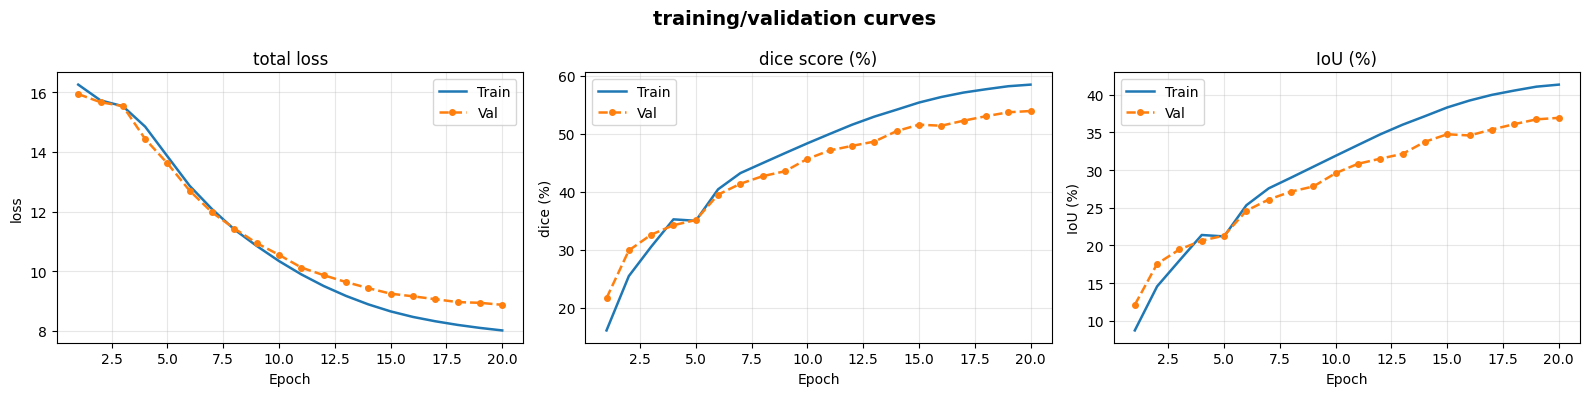

curves saved


In [35]:
history = TRAINER.history

epochs_all = [r["epoch"] for r in history]
train_loss = [r["train"].get("total", 0) for r in history]
train_dice = [r["train"].get("Dice", 0) for r in history]
train_iou = [r["train"].get("IoU", 0) for r in history]

val_epochs = [r["epoch"] for r in history if "val" in r]
val_loss = [r["val"].get("total", 0) for r in history if "val" in r]
val_dice = [r["val"].get("Dice", 0) for r in history if "val" in r]
val_iou = [r["val"].get("IoU", 0) for r in history if "val" in r]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("training/validation curves", fontsize=14, fontweight="bold")

for ax, tr_y, vl_y, vl_x, title, ylabel in zip(
    axes,
    [train_loss, train_dice, train_iou],
    [val_loss, val_dice, val_iou],
    [val_epochs, val_epochs, val_epochs],
    ["total loss", "dice score (%)", "IoU (%)"],
    ["loss", "dice (%)", "IoU (%)"],
):
    ax.plot(epochs_all, tr_y, label="Train", linewidth=1.8)
    if vl_y:
        ax.plot(vl_x, vl_y, label="Val", linewidth=1.8, linestyle="--", marker="o", markersize=4)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(Path(CFG["output_dir"]) / "training_curves.png", dpi=150)
plt.show()
print("curves saved")